In [2]:
from keras.datasets import mnist
import numpy as np

(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

train_images_with_noise_channels = np.concatenate(
    [train_images, np.random.random((len(train_images), 784))], axis=1
)

train_images_with_zeros_channels = np.concatenate(
    [train_images, np.zeros((len(train_images), 784))], axis=1
)

Skal vise at en modell gjør det dårlig med meye støy vs lite/ ingen støy!

In [3]:
import keras
from keras import layers

def get_model():
    model = keras.Sequential(
        [
            layers.Dense(512, activation="relu"),
            layers.Dense(10, activation="softmax"),
        ]
    )
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

model = get_model()
history_noise = model.fit(
    train_images_with_noise_channels,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
)

model = get_model()
history_zeros = model.fit(
    train_images_with_zeros_channels,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8639 - loss: 0.4505 - val_accuracy: 0.9124 - val_loss: 0.2890
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9282 - loss: 0.2376 - val_accuracy: 0.9436 - val_loss: 0.1977
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9540 - loss: 0.1574 - val_accuracy: 0.9476 - val_loss: 0.1774
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9658 - loss: 0.1151 - val_accuracy: 0.9567 - val_loss: 0.1435
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9759 - loss: 0.0820 - val_accuracy: 0.9494 - val_loss: 0.1668
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9834 - loss: 0.0586 - val_accuracy: 0.9538 - val_loss: 0.1506
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9882 - loss: 0.0432 - val_accuracy: 0.9593 - val_loss: 0.1404
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9917 - loss: 0.0306 - val_accuracy: 0.

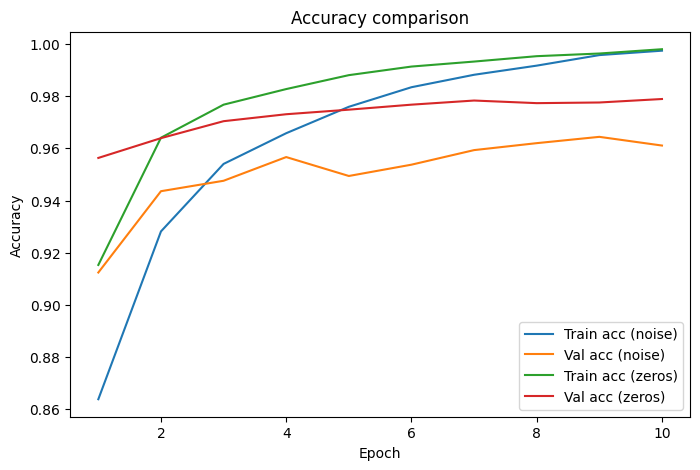

In [4]:
import matplotlib.pyplot as plt

epochs = range(1, len(history_noise.history["loss"]) + 1)

plt.figure(figsize=(8,5))

plt.plot(epochs, history_noise.history["accuracy"], label="Train acc (noise)")
plt.plot(epochs, history_noise.history["val_accuracy"], label="Val acc (noise)")

plt.plot(epochs, history_zeros.history["accuracy"], label="Train acc (zeros)")
plt.plot(epochs, history_zeros.history["val_accuracy"], label="Val acc (zeros)")

plt.title("Accuracy comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

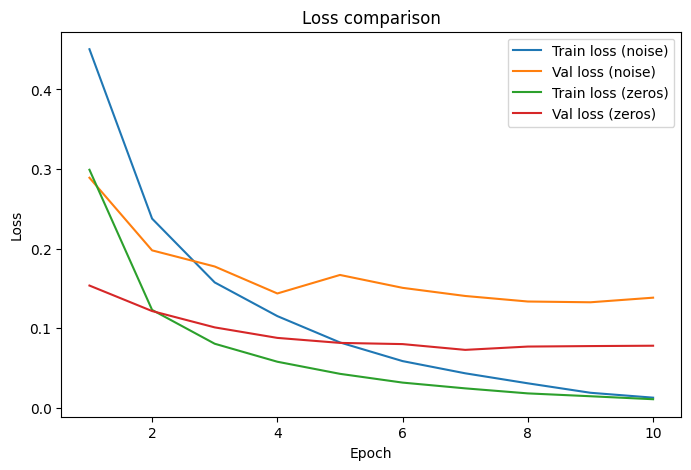

In [5]:
plt.figure(figsize=(8,5))

plt.plot(epochs, history_noise.history["loss"], label="Train loss (noise)")
plt.plot(epochs, history_noise.history["val_loss"], label="Val loss (noise)")

plt.plot(epochs, history_zeros.history["loss"], label="Train loss (zeros)")
plt.plot(epochs, history_zeros.history["val_loss"], label="Val loss (zeros)")

plt.title("Loss comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


Viser at NN kan lære mønstre med tilfeldige data. vi forventer at treningssettet går nær 100% accuracy og nær 0 på loss, men motsatt for valideringssettet!

In [7]:
(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

# Copies train_labels
random_train_labels = train_labels[:]
np.random.shuffle(random_train_labels)

model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history = model.fit(
    train_images,
    random_train_labels,
    epochs=100,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1034 - loss: 2.3157 - val_accuracy: 0.1102 - val_loss: 2.3060
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1176 - loss: 2.2988 - val_accuracy: 0.1053 - val_loss: 2.3094
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1269 - loss: 2.2909 - val_accuracy: 0.1068 - val_loss: 2.3202
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1385 - loss: 2.2795 - val_accuracy: 0.0968 - val_loss: 2.3262
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1508 - loss: 2.2644 - val_accuracy: 0.1042 - val_loss: 2.3363
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1644 - loss: 2.2451 - val_accuracy: 0.1046 - val_loss: 2.3487
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1821 - loss: 2.2221 - val_accuracy: 0.1009 - val_loss: 2.3666
Epoch 8/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1972 - loss: 2.1959 - val_accu

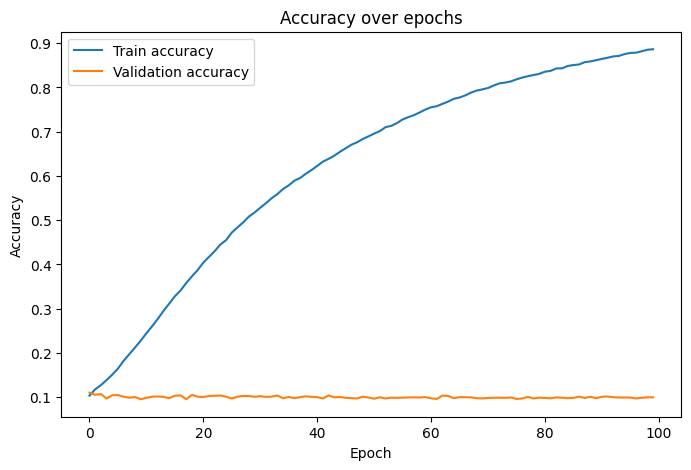

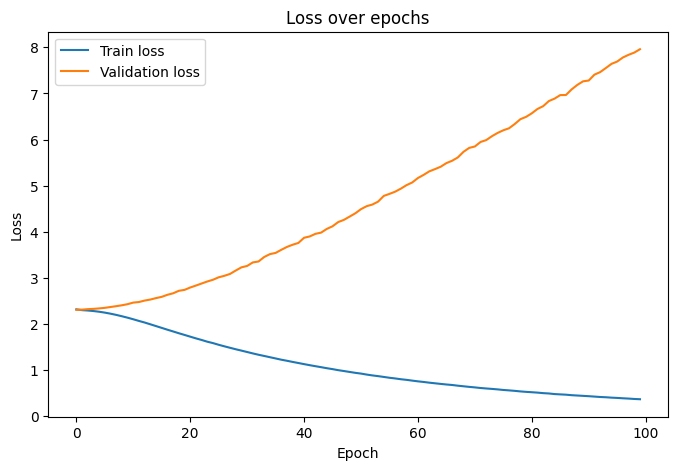

In [8]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Train accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.title("Accuracy over epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.title("Loss over epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

Skal vise at man må være oppmerksom på leraning_rate. learningrate på 1.0 gjør det veldig dårlig, men samme kode med learningreate på 0.001 gjør det mye bedre!

In [9]:
(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1.0),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images, train_labels, epochs=10, batch_size=128, validation_split=0.2
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3478 - loss: 509.7170 - val_accuracy: 0.2594 - val_loss: 2.3512
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2287 - loss: 3.4494 - val_accuracy: 0.1935 - val_loss: 2.8072
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2264 - loss: 2.5169 - val_accuracy: 0.1823 - val_loss: 2.2176
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1930 - loss: 2.4751 - val_accuracy: 0.2231 - val_loss: 2.2661
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2098 - loss: 2.4425 - val_accuracy: 0.2402 - val_loss: 3.0025
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2017 - loss: 2.8354 - val_accuracy: 0.1846 - val_loss: 2.1986
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2209 - loss: 2.4978 - val_accuracy: 0.2053 - val_loss: 2.2015
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2007 - loss: 2.5324 - val_accuracy: 

In [11]:
(_, _), (test_images, test_labels) = mnist.load_data()

test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype("float32") / 255

model.evaluate(test_images, test_labels)
from sklearn.metrics import confusion_matrix
import numpy as np

predictions = model.predict(test_images)
predicted_labels = np.argmax(predictions, axis=1)

cm = confusion_matrix(test_labels, predicted_labels)
print(cm)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 634us/step - accuracy: 0.1761 - loss: 2.3652
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 520us/step
[[  69    0    0    0    0  911    0    0    0    0]
 [   0  782    0    0    0  353    0    0    0    0]
 [   0    0    4    0    0 1028    0    0    0    0]
 [   0    0    0    1    0 1009    0    0    0    0]
 [   0    0    0    0    2  980    0    0    0    0]
 [   0    0    0    0    0  892    0    0    0    0]
 [   0    1    0    0    0  949    8    0    0    0]
 [   0    1    0    0    0 1024    0    3    0    0]
 [   0    0    0    0    0  974    0    0    0    0]
 [   0    0    0    0    0 1009    0    0    0    0]]


In [12]:
model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1e-2),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images, train_labels, epochs=10, batch_size=128, validation_split=0.2
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9104 - loss: 0.3377 - val_accuracy: 0.9579 - val_loss: 0.1520
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9658 - loss: 0.1203 - val_accuracy: 0.9675 - val_loss: 0.1263
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9747 - loss: 0.0942 - val_accuracy: 0.9707 - val_loss: 0.1318
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9797 - loss: 0.0806 - val_accuracy: 0.9705 - val_loss: 0.1493
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9830 - loss: 0.0675 - val_accuracy: 0.9687 - val_loss: 0.1752
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9852 - loss: 0.0632 - val_accuracy: 0.9707 - val_loss: 0.1879
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9869 - loss: 0.0582 - val_accuracy: 0.9705 - val_loss: 0.2035
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9887 - loss: 0.0482 - val_accuracy: 0.

In [13]:
(_, _), (test_images, test_labels) = mnist.load_data()

test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype("float32") / 255

model.evaluate(test_images, test_labels)
from sklearn.metrics import confusion_matrix
import numpy as np

predictions = model.predict(test_images)
predicted_labels = np.argmax(predictions, axis=1)

cm = confusion_matrix(test_labels, predicted_labels)
print(cm)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 658us/step - accuracy: 0.9727 - loss: 0.2414  
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 554us/step
[[ 963    0    8    1    0    0    3    1    4    0]
 [   0 1126    2    2    0    0    1    2    2    0]
 [   0    1 1011    3    3    0    2    7    5    0]
 [   0    0    3  997    0    1    0    3    4    2]
 [   2    6    5    0  946    0    3    4    2   14]
 [   2    0    0   22    1  850    4    0    8    5]
 [   3    3    0    1    4    8  935    2    2    0]
 [   0    0    7    2    1    1    0 1010    3    4]
 [   2    1    7   14    0    3    2    8  932    5]
 [   3    5    0    8    4    4    0   23    5  957]]


bruker L2 regularisering for å redusere overfitting

In [17]:
from keras.regularizers import l2
from keras.datasets import imdb

(train_data, train_labels), _ = imdb.load_data(num_words=10000)
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.0
    return results

train_data = vectorize_sequences(train_data)

model = keras.Sequential(
    [
        layers.Dense(16, kernel_regularizer=l2(0.002), activation="relu"),
        layers.Dense(16, kernel_regularizer=l2(0.002), activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_l2_reg = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7713 - loss: 0.6201 - val_accuracy: 0.8523 - val_loss: 0.4946
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8887 - loss: 0.4185 - val_accuracy: 0.8696 - val_loss: 0.4180
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9111 - loss: 0.3443 - val_accuracy: 0.8869 - val_loss: 0.3726
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9251 - loss: 0.3019 - val_accuracy: 0.8889 - val_loss: 0.3606
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9313 - loss: 0.2811 - val_accuracy: 0.8870 - val_loss: 0.3585
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9374 - loss: 0.2659 - val_accuracy: 0.8838 - val_loss: 0.3663
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9390 - loss: 0.2575 - val_accuracy: 0.8838 - val_loss: 0.3677
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9433 - loss: 0.2463 - val_accuracy: 0.8820 - val_loss

Dropout(0.5) bet

In [18]:
model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(16, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_dropout = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5940 - loss: 0.6528 - val_accuracy: 0.8336 - val_loss: 0.5449
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7211 - loss: 0.5483 - val_accuracy: 0.8608 - val_loss: 0.4393
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7792 - loss: 0.4741 - val_accuracy: 0.8795 - val_loss: 0.3836
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8273 - loss: 0.4143 - val_accuracy: 0.8865 - val_loss: 0.3237
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8592 - loss: 0.3636 - val_accuracy: 0.8847 - val_loss: 0.2979
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8803 - loss: 0.3282 - val_accuracy: 0.8831 - val_loss: 0.2924
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8983 - loss: 0.2906 - val_accuracy: 0.8840 - val_loss: 0.2855
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9148 - loss: 0.2625 - val_accuracy: 0.8917 - val_loss